In [48]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
spark = SparkSession.builder.appName("modelling").config("spark.driver.memory", "12g").getOrCreate()

In [2]:
yellow_taxi_data = spark.read.parquet('cleaned_data/yellow_data.parquet')
yellow_taxi_data.show(1)

+-------------------+------------+------------+-------+
|               date|PULocationID|total_amount|Borough|
+-------------------+------------+------------+-------+
|2023-05-01 00:42:49|         138|       57.15| Queens|
+-------------------+------------+------------+-------+
only showing top 1 row


In [3]:
from utils import add_stations
# aggregate to daily
yellow_taxi_daily_earnings = (
    yellow_taxi_data
    .withColumn("date", F.to_date("date"))
    .groupBy("date", "PULocationID", 'Borough')
    .agg(F.sum("total_amount").alias("daily_total_amount"))
    .orderBy("date")
)
yellow_taxi_daily_earnings = add_stations(yellow_taxi_daily_earnings, spark)

residential_data = spark.read.csv('cleaned_data/residential_data.csv', header=True, inferSchema=True)
residential_data = residential_data.withColumn("residential_density", F.col("TotalResidentialUnits") / F.col("TotalNumBldgs"))
residential_data = residential_data.select('LocationID', 'residential_density')
training_data = yellow_taxi_daily_earnings.join(residential_data, yellow_taxi_daily_earnings.PULocationID == residential_data.LocationID, 'left').drop('LocationID')

# drop rows where residential_density is null
print('Shape', training_data.count(), ',', len(training_data.columns))
training_data.show(2)

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:659: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:936: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_versi

Shape 262332 , 6


+----------+------------+---------+------------------+------------+-------------------+
|      date|PULocationID|  Borough|daily_total_amount|num_stations|residential_density|
+----------+------------+---------+------------------+------------+-------------------+
|2023-05-01|         165| Brooklyn|            128.86|           3| 2.4132334581772783|
|2023-05-02|          79|Manhattan| 36476.00999999998|           2| 16.148442272449604|
+----------+------------+---------+------------------+------------+-------------------+
only showing top 2 rows


In [4]:
# remove all areas that have NULL residential_density except with PULocationID 1, 132 or 138
training_data = training_data.filter(~((F.col('residential_density').isNull()) & (~F.col('PULocationID').isin([1, 132, 138]))))
# create a new column called isAirport that is 1 if PULocationID is 132, 1 or 138, else 0
training_data = training_data.withColumn('isAirport', F.when(F.col('PULocationID').isin([132, 1, 138]), 1).otherwise(0))

# replace null values in residential_density with 0
training_data = training_data.fillna({'residential_density': 0})
print('Shape', training_data.count(), ',', len(training_data.columns))

Shape 252380 , 7


In [5]:
fhvhv_taxi_data = spark.read.parquet('cleaned_data/fhvhv_data.parquet')
fhvhv_taxi_data = fhvhv_taxi_data.withColumn("date", F.to_date("date"))
fhvhv_trip_volume = (
    fhvhv_taxi_data
    .groupBy("date", "PULocationID")
    .agg(F.count("*").alias("daily_trip_volume"))
    .orderBy("date")
)
fhvhv_taxi_data.show()

+----------+------------+
|      date|PULocationID|
+----------+------------+
|2023-03-01|         114|
|2023-03-01|          79|
|2023-03-01|         113|
|2023-03-01|         229|
|2023-03-01|         144|
|2023-03-01|           7|
|2023-03-01|         255|
|2023-03-01|         255|
|2023-03-01|          80|
|2023-03-01|         255|
|2023-03-01|          80|
|2023-03-01|         255|
|2023-03-01|         231|
|2023-03-01|         229|
|2023-03-01|          36|
|2023-03-01|         112|
|2023-03-01|         141|
|2023-03-01|         161|
|2023-03-01|          75|
|2023-03-01|         139|
+----------+------------+
only showing top 20 rows


In [6]:
training_data = training_data.join(
    fhvhv_trip_volume,
    on=["date", "PULocationID"],
    how='inner'
)
print('Shape', training_data.count(), ',', len(training_data.columns))
training_data.show()

Shape 252103 , 8


+----------+------------+---------+------------------+------------+-------------------+---------+-----------------+
|      date|PULocationID|  Borough|daily_total_amount|num_stations|residential_density|isAirport|daily_trip_volume|
+----------+------------+---------+------------------+------------+-------------------+---------+-----------------+
|2023-01-01|          11| Brooklyn|              42.6|           0| 2.4930684874818954|        0|              703|
|2023-01-01|          24|Manhattan|3790.2100000000014|           1|  25.82941176470588|        0|              906|
|2023-01-01|          91| Brooklyn|              54.0|           0| 1.4156811499509965|        0|             3037|
|2023-01-01|         123| Brooklyn|             43.65|           1|  2.507860262008734|        0|             1721|
|2023-01-01|         137|Manhattan| 20404.77999999995|           0| 35.746736292428196|        0|             3458|
|2023-01-01|         174|    Bronx|              35.4|           3|  16.

In [55]:
training_data_final = training_data
training_data_final = training_data_final.withColumn("log_daily_total_amount", F.log1p("daily_total_amount"))
training_data_final = training_data_final.withColumn("log_daily_trip_volume", F.log1p("daily_trip_volume"))
training_data_final = training_data_final.withColumn("has_station", F.when(F.col("num_stations") > 0, 1).otherwise(0))
# add month and day of week columns
training_data_final = training_data_final.withColumn("day_of_week", F.dayofweek("date"))
training_data_final = training_data_final.withColumn("month", F.month("date"))
X_train = training_data_final.drop('daily_total_amount', 'daily_trip_volume', 'date', 'num_stations', 'PULocationID')
X_train.show()

+---------+-------------------+---------+----------------------+---------------------+-----------+-----------+-----+
|  Borough|residential_density|isAirport|log_daily_total_amount|log_daily_trip_volume|has_station|day_of_week|month|
+---------+-------------------+---------+----------------------+---------------------+-----------+-----------+-----+
| Brooklyn| 2.4930684874818954|        0|     3.775057150354989|    6.556778356158042|          0|          1|    1|
|Manhattan|  25.82941176470588|        0|     8.240440508337176|    6.810142450115136|          1|          1|    1|
| Brooklyn| 1.4156811499509965|        0|     4.007333185232471|    8.018954683155718|          0|          1|    1|
| Brooklyn|  2.507860262008734|        0|     3.798854307322508|    7.451241684987676|          1|          1|    1|
|Manhattan| 35.746736292428196|        0|      9.92357347303433|    8.148734808937169|          0|          1|    1|
|    Bronx|  16.83679833679834|        0|     3.594568774642695|

In [56]:
X_train_pd = X_train.toPandas()

In [57]:
# Path containing all Parquet files
input_path_fhvhv = "data/year-2026-fhvhv"
input_path_yellow = "data/year-2026-yellow"

# Read and concatenate all Parquet files into a single DataFrame
data_2026_raw = spark.read.parquet(input_path_fhvhv)
data_2026_raw = data_2026_raw.select('pickup_datetime', 'PULocationID')

# calculate daily trip volume per PULocationID
data_2026_raw = (
    data_2026_raw
    .withColumn("date", F.to_date("pickup_datetime"))
    .groupBy("date", "PULocationID")
    .agg(F.count("*").alias("daily_trip_volume"))
    .orderBy("date")
)

print(f"Number of rows: {data_2026_raw.count()}")
print(f"Number of columns: {len(data_2026_raw.columns)}")

Number of rows: 39070
Number of columns: 3


In [22]:
yellow_taxi_data_2026 = spark.read.parquet(input_path_yellow)
yellow_taxi_data_2026 = yellow_taxi_data_2026.withColumn("date", F.to_date("tpep_pickup_datetime"))
yellow_taxi_daily_earnings_2026 = (
    yellow_taxi_data_2026
    .groupBy("date", "PULocationID")
    .agg(F.sum("total_amount").alias("daily_total_amount"))
    .orderBy("date")
)
yellow_taxi_daily_earnings_2026 = add_stations(yellow_taxi_daily_earnings_2026, spark)
# add residential density by using training_data as a lookup
yellow_taxi_daily_earnings_2026 = yellow_taxi_daily_earnings_2026.join(
    residential_data,
    yellow_taxi_daily_earnings_2026.PULocationID == residential_data.LocationID,
    'left'
).drop('LocationID')
# add isAirport column
yellow_taxi_daily_earnings_2026 = yellow_taxi_daily_earnings_2026.withColumn('isAirport', F.when(F.col('PULocationID').isin([132, 1, 138]), 1).otherwise(0))
# remove all areas that have NULL residential_density except with PULocationID 1, 132 or 138
yellow_taxi_daily_earnings_2026 = yellow_taxi_daily_earnings_2026.filter(~((F.col('residential_density').isNull()) & (~F.col('PULocationID').isin([1, 132, 138]))))
# replace null values in residential_density with 0
yellow_taxi_daily_earnings_2026 = yellow_taxi_daily_earnings_2026.fillna({'residential_density': 0})
# add the Borough column by using training_data as a lookup
yellow_taxi_daily_earnings_2026 = yellow_taxi_daily_earnings_2026.join(
    training_data.select('PULocationID', 'Borough').distinct(),
    on='PULocationID',
    how='left'
)
# add trip volume
test_data = yellow_taxi_daily_earnings_2026.join(
    data_2026_raw,
    on=["date", "PULocationID"],
    how='inner'
)
# add log columns
test_data = test_data.withColumn("log_daily_total_amount", F.log1p("daily_total_amount"))
test_data = test_data.withColumn("log_daily_trip_volume", F.log1p("daily_trip_volume"))
test_data = test_data.withColumn("has_station", F.when(F.col("num_stations") > 0, 1).otherwise(0))
# add month and day of week columns

test_data = test_data.withColumn("day_of_week", F.dayofweek("date"))
test_data = test_data.withColumn("month", F.month("date"))
# drop unnecessary columns
test_data = test_data.drop('daily_total_amount', 'daily_trip_volume', 'date', 'num_stations', 'PULocationID')
test_data.show(2)

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:659: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:936: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_versi

+-------------------+---------+--------+----------------------+---------------------+-----------+-----------+-----+
|residential_density|isAirport| Borough|log_daily_total_amount|log_daily_trip_volume|has_station|day_of_week|month|
+-------------------+---------+--------+----------------------+---------------------+-----------+-----------+-----+
|  2.588637266587207|        0|Brooklyn|     6.262121257090876|    7.404887575616125|          1|          7|    5|
|  2.588637266587207|        0|Brooklyn|    7.4497248557411115|    8.446985296372741|          1|          3|    5|
+-------------------+---------+--------+----------------------+---------------------+-----------+-----------+-----+
only showing top 2 rows


In [58]:
import numpy as np
X_test = test_data.toPandas()
X_test = X_test.loc[X_test['Borough'] == 'Manhattan']
X_test.drop(['Borough'], axis=1, inplace=True)
y_test = X_test.pop('log_daily_total_amount')
predictions = model.predict(X_test)

# evaluate the model using RMSE, R squared and MAE
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print(f"RMSE: {rmse}")
print(f"R²: {r2}")
print(f"MAE: {mae}")

RMSE: 6.705421088565436
R²: -29.145431842659335
MAE: 6.599430459988729


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Prepare training data
X_train = X_train_pd.copy()
y_train = X_train.pop('log_daily_total_amount')

# Prepare test data
X_test = test_data.toPandas()
y_test = X_test.pop('log_daily_total_amount')

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# Define numeric and categorical features
numeric_features = ['has_station', 'residential_density', 'isAirport', 'log_daily_trip_volume', 
                    'day_of_week', 'month']
categorical_features = ['Borough']

# Create preprocessing pipeline with one-hot encoding for Borough
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features)
    ]
)

# Create full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ))
])

# Train on full dataset
pipeline.fit(X_train, y_train)

# Cross-validation on training data
print("\nCross-validation (5-fold):")
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
print(f"  CV R² scores: {cv_scores}")
print(f"  Mean CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Evaluate on test data
print("TEST SET EVALUATION")

y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"\nRMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")

Training set size: 252103
Test set size: 34312

Cross-validation (5-fold):
  CV R² scores: [0.9419097  0.94151619 0.94145955 0.94029108 0.94120951]
  Mean CV R²: 0.9413 ± 0.0005
TEST SET EVALUATION

RMSE: 1.5487
R²: 0.3650
MAE: 1.3793


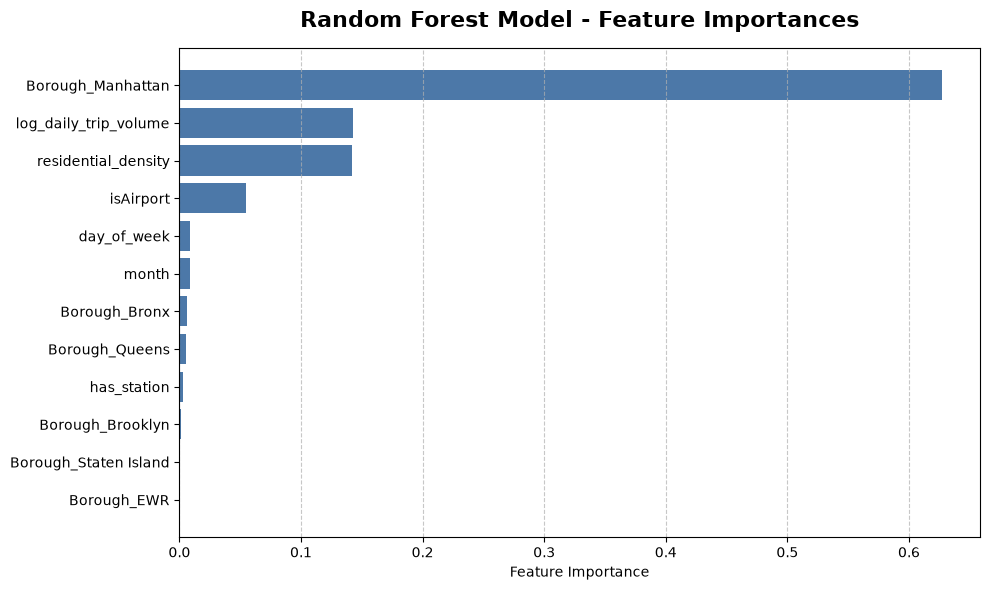

In [67]:
# Feature importance
rf_model = pipeline.named_steps['regressor']
feature_importances = rf_model.feature_importances_

# Get feature names after preprocessing
feature_names = numeric_features.copy()
# Add borough one-hot encoded names
encoder = pipeline.named_steps['preprocessor'].named_transformers_['cat']
borough_names = [f"Borough_{b}" for b in encoder.categories_[0]]
feature_names.extend(borough_names)

# Create DataFrame and sort
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
importance_df_sorted = importance_df.sort_values('Importance')
plt.barh(importance_df_sorted['Feature'], importance_df_sorted['Importance'], color='#4C78A8')
plt.xlabel('Feature Importance')
plt.title('Random Forest Model - Feature Importances', fontsize=16, fontweight='bold', pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import SplineTransformer
from sklearn.metrics import r2_score, mean_squared_error

# Convert PySpark to Pandas
X_train = X_train_pd.copy()
X_train = X_train.loc[X_train['Borough'] == 'Manhattan'].copy()
X_train.drop(['Borough'], axis=1, inplace=True)
y_train = y.copy()

print("="*70)
print("ADDRESSING NON-LINEARITY IN TRIP VOLUME")
print("="*70)

# Store results
results = []

# ============================================================================
# Approach 1: Polynomial Features
# ============================================================================
print("\n1. POLYNOMIAL FEATURES")
print("-"*70)

X_train_poly = X_train.copy()
X_test_poly = X_test.copy()

X_train_poly['trip_volume_squared'] = X_train_poly['log_daily_trip_volume'] ** 2
X_train_poly['trip_volume_cubed'] = X_train_poly['log_daily_trip_volume'] ** 3

X_test_poly['trip_volume_squared'] = X_test_poly['log_daily_trip_volume'] ** 2
X_test_poly['trip_volume_cubed'] = X_test_poly['log_daily_trip_volume'] ** 3

rf_poly = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf_poly.fit(X_train_poly, y_train)

y_pred_poly = rf_poly.predict(X_test_poly)
r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print(f"Test R²: {r2_poly:.4f} (vs baseline 0.42)")
print(f"Test RMSE: {rmse_poly:.4f}")

results.append({'Approach': 'Polynomial Features', 'Test R²': r2_poly, 'RMSE': rmse_poly})

# ============================================================================
# Approach 2: Binning Trip Volume
# ============================================================================
print("\n2. BINNING TRIP VOLUME")
print("-"*70)

X_train_bin = X_train.copy()
X_test_bin = X_test.copy()

X_train_bin['trip_volume_bin'] = pd.cut(X_train_bin['log_daily_trip_volume'], 
                                         bins=4, labels=['low', 'med', 'high', 'very_high'])
X_test_bin['trip_volume_bin'] = pd.cut(X_test_bin['log_daily_trip_volume'], 
                                        bins=4, labels=['low', 'med', 'high', 'very_high'])

X_train_bin = pd.get_dummies(X_train_bin, columns=['trip_volume_bin'], drop_first=False)
X_test_bin = pd.get_dummies(X_test_bin, columns=['trip_volume_bin'], drop_first=False)

# Align columns
for col in X_train_bin.columns:
    if col not in X_test_bin.columns:
        X_test_bin[col] = 0
for col in X_test_bin.columns:
    if col not in X_train_bin.columns:
        X_train_bin[col] = 0

X_train_bin = X_train_bin[sorted(X_train_bin.columns)]
X_test_bin = X_test_bin[sorted(X_test_bin.columns)]

rf_bin = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf_bin.fit(X_train_bin, y_train)

y_pred_bin = rf_bin.predict(X_test_bin)
r2_bin = r2_score(y_test, y_pred_bin)
rmse_bin = np.sqrt(mean_squared_error(y_test, y_pred_bin))

print(f"Test R²: {r2_bin:.4f} (vs baseline 0.42)")
print(f"Test RMSE: {rmse_bin:.4f}")

results.append({'Approach': 'Binning Trip Volume', 'Test R²': r2_bin, 'RMSE': rmse_bin})

# ============================================================================
# Approach 3: Spline Transformation
# ============================================================================
print("\n3. SPLINE TRANSFORMATION")
print("-"*70)

X_train_spline = X_train.copy()
X_test_spline = X_test.copy()

spline_transformer = SplineTransformer(n_knots=4, degree=3, include_bias=False)
trip_volume_spline_train = spline_transformer.fit_transform(
    X_train_spline[['log_daily_trip_volume']]
)
trip_volume_spline_test = spline_transformer.transform(
    X_test_spline[['log_daily_trip_volume']]
)

X_train_spline = X_train_spline.drop('log_daily_trip_volume', axis=1)
X_test_spline = X_test_spline.drop('log_daily_trip_volume', axis=1)

for i in range(trip_volume_spline_train.shape[1]):
    X_train_spline[f'trip_volume_spline_{i}'] = trip_volume_spline_train[:, i]
    X_test_spline[f'trip_volume_spline_{i}'] = trip_volume_spline_test[:, i]

rf_spline = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf_spline.fit(X_train_spline, y_train)

y_pred_spline = rf_spline.predict(X_test_spline)
r2_spline = r2_score(y_test, y_pred_spline)
rmse_spline = np.sqrt(mean_squared_error(y_test, y_pred_spline))

print(f"Test R²: {r2_spline:.4f} (vs baseline 0.42)")
print(f"Test RMSE: {rmse_spline:.4f}")

results.append({'Approach': 'Spline Transformation', 'Test R²': r2_spline, 'RMSE': rmse_spline})

# ============================================================================
# Approach 4: Interaction Terms
# ============================================================================
print("\n4. INTERACTION TERMS")
print("-"*70)

X_train_inter = X_train.copy()
X_test_inter = X_test.copy()

X_train_inter['trip_vol_x_density'] = X_train_inter['log_daily_trip_volume'] * X_train_inter['residential_density']
X_train_inter['trip_vol_x_dow'] = X_train_inter['log_daily_trip_volume'] * X_train_inter['day_of_week']

X_test_inter['trip_vol_x_density'] = X_test_inter['log_daily_trip_volume'] * X_test_inter['residential_density']
X_test_inter['trip_vol_x_dow'] = X_test_inter['log_daily_trip_volume'] * X_test_inter['day_of_week']

rf_inter = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf_inter.fit(X_train_inter, y_train)

y_pred_inter = rf_inter.predict(X_test_inter)
r2_inter = r2_score(y_test, y_pred_inter)
rmse_inter = np.sqrt(mean_squared_error(y_test, y_pred_inter))

print(f"Test R²: {r2_inter:.4f} (vs baseline 0.42)")
print(f"Test RMSE: {rmse_inter:.4f}")

results.append({'Approach': 'Interaction Terms', 'Test R²': r2_inter, 'RMSE': rmse_inter})

# ============================================================================
# Summary
# ============================================================================
print("\n" + "="*70)
print("SUMMARY")
print("="*70)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test R²', ascending=False)
print("\n" + results_df.to_string(index=False))

print(f"\nBaseline (original RF): R² = 0.42")
best_approach = results_df.iloc[0]
improvement = (best_approach['Test R²'] - 0.42) / 0.42 * 100
print(f"\nBest approach: {best_approach['Approach']}")
print(f"Improvement: {improvement:+.1f}%")

ADDRESSING NON-LINEARITY IN TRIP VOLUME

1. POLYNOMIAL FEATURES
----------------------------------------------------------------------
Test R²: 0.4132 (vs baseline 0.42)
Test RMSE: 0.9356

2. BINNING TRIP VOLUME
----------------------------------------------------------------------
Test R²: 0.4133 (vs baseline 0.42)
Test RMSE: 0.9355

3. SPLINE TRANSFORMATION
----------------------------------------------------------------------
Test R²: 0.4126 (vs baseline 0.42)
Test RMSE: 0.9360

4. INTERACTION TERMS
----------------------------------------------------------------------
Test R²: 0.4143 (vs baseline 0.42)
Test RMSE: 0.9346

SUMMARY

             Approach  Test R²     RMSE
    Interaction Terms 0.414347 0.934621
  Binning Trip Volume 0.413266 0.935483
  Polynomial Features 0.413151 0.935575
Spline Transformation 0.412638 0.935984

Baseline (original RF): R² = 0.42

Best approach: Interaction Terms
Improvement: -1.3%


# Model 2: